# Customer Churn Risk Analysis and Prediction

This project analyzes customer behavior to understand churn patterns and build a machine learning model that predicts whether a customer is likely to leave.

The main goal is not only to build a prediction model, but also to identify useful business insights that can help reduce customer churn.

## Project Objectives

- Understand the structure of the customer churn dataset
- Explore patterns between customer features and churn
- Clean and prepare the data for machine learning
- Train classification models to predict churn
- Evaluate model performance using suitable metrics
- Explain important factors that influence customer churn

In [1]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the dataset
df = pd.read_csv("../data/customer_churn.csv")
df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [3]:
#checking the shape of the dataset
df.shape

(900, 10)

In [4]:
#checking the info of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 70.4 KB


In [5]:
#checking the statistical summary of the dataset
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [6]:
#checking for missing values in the dataset
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

The dataset contains customer-related information such as age, total purchase amount, account manager status, number of years with the company, number of sites, and churn status.

In [ ]:
# checking the distribution of the churn variable
df["Churn"].value_counts()

Churn
0    750
1    150
Name: count, dtype: int64

In [ ]:
# checking the percentage distribution of the churn variable
df["Churn"].value_counts(normalize=True) * 100

Churn
0    83.333333
1    16.666667
Name: proportion, dtype: float64

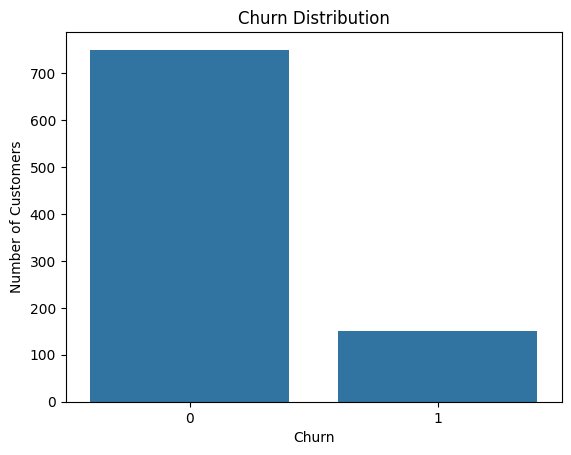

In [9]:
# visualizing the distribution of the Churn variable
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.savefig("../images/churn_distribution.png", bbox_inches="tight")
plt.show()

The target variable is Churn. A value of 1 means the customer left, while 0 means the customer stayed. Checking the distribution helps understand whether the dataset is balanced or imbalanced.